Dengan ini, saya yang bernama Lauren Abigail dengan NIM 2602108426, dengan sungguh-sungguh berjanji bahwa file yang saya submit adalah hasil karya saya sendiri dan bukan merupakan salinan dari pekerjaan teman saya.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Exploration

In [36]:
df = pd.read_csv('./Global_Education_Dataset_UAS.csv')
df.head()

,Countries and areas,Latitude,Longitude,OOSR_Pre0Primary_Age_Male,OOSR_Pre0Primary_Age_Female,OOSR_Primary_Age_Male,OOSR_Primary_Age_Female,OOSR_Lower_Secondary_Age_Male,OOSR_Lower_Secondary_Age_Female,OOSR_Upper_Secondary_Age_Male,...,Primary_End_Proficiency_Reading,Primary_End_Proficiency_Math,Lower_Secondary_End_Proficiency_Reading,Lower_Secondary_End_Proficiency_Math,Youth_15_24_Literacy_Rate_Male,Youth_15_24_Literacy_Rate_Female,Birth_Rate,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment,Unemployment_Rate
0,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,44,...,13,11,0,0,74,56,32.49,very high,extremely low,moderately low
1,Albania,41.153332,20.168331,4,2,6,3,6,1,21,...,0,0,48,58,99,100,11.78,very high,moderately low,moderate
2,Algeria,28.033886,1.659626,0,0,0,0,0,0,0,...,0,0,21,19,98,97,24.28,very high,moderately low,moderately low
3,Andorra,42.506285,1.521801,0,0,0,0,0,0,0,...,0,0,0,0,0,0,7.20,very high,extremely low,extremely low
4,Angola,11.202692,17.873887,31,39,0,0,0,0,0,...,0,0,0,0,0,0,40.73,very high,extremely low,low


In [37]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, df[col].unique())

Countries and areas ['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola' 'Anguilla'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'The Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'British Virgin Islands' 'Brunei' 'Bulgaria'
 'Burkina Faso' 'Burundi' 'Cape Verde' 'Cambodia' 'Cameroon' 'Canada'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Republic of the Congo' 'Cook Islands' 'Costa Rica' 'Ivory Coast'
 'Croatia' 'Cuba' 'Cyprus' 'Czech Republic' 'North Korea'
 'Democratic Republic of the Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Fiji' 'Finland' 'France'
 'Gabon' 'The Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada'
 'Guatemala' 'Guinea' 'Guinea0Bissau' 'Guyana' 'Haiti' 'Vatican City'
 'Honduras' 'Hungary'

# Feature Engineering

In [38]:
map_dict = {'extremely high': 1, 
            'ultra high': 2, 
            'very high': 3, 
            'high': 4, 
            'moderately high': 5, 
            'moderate': 6, 
            'moderately low': 7, 
            'low': 8, 
            'very low': 9,
            'extremely low' : 10}


## Dropping useless features

In [39]:
df = df.drop(["Countries and areas", 'Latitude ', 'Longitude'], axis=1)

Drop karena fitur hanya berguna sebagai index

## Encoding categorical features

In [40]:
object_cols = []
for col in df.columns:
    if df[col].dtype == 'object':
        object_cols.append(col)

In [41]:
df[object_cols] = df[object_cols].replace(map_dict)

In [42]:
df.head()

,OOSR_Pre0Primary_Age_Male,OOSR_Pre0Primary_Age_Female,OOSR_Primary_Age_Male,OOSR_Primary_Age_Female,OOSR_Lower_Secondary_Age_Male,OOSR_Lower_Secondary_Age_Female,OOSR_Upper_Secondary_Age_Male,OOSR_Upper_Secondary_Age_Female,Completion_Rate_Primary_Male,Completion_Rate_Primary_Female,...,Primary_End_Proficiency_Reading,Primary_End_Proficiency_Math,Lower_Secondary_End_Proficiency_Reading,Lower_Secondary_End_Proficiency_Math,Youth_15_24_Literacy_Rate_Male,Youth_15_24_Literacy_Rate_Female,Birth_Rate,Gross_Primary_Education_Enrollment,Gross_Tertiary_Education_Enrollment,Unemployment_Rate
0,0,0,0,0,0,0,44,69,4,7,...,13,11,0,0,74,56,32.49,3,10,7
1,4,2,6,3,6,1,21,15,2,2,...,0,0,48,58,99,100,11.78,3,7,6
2,0,0,0,0,0,0,0,0,2,2,...,0,0,21,19,98,97,24.28,3,7,7
3,0,0,0,0,0,0,0,0,10,10,...,0,0,0,0,0,0,7.20,3,10,10
4,31,39,0,0,0,0,0,0,4,5,...,0,0,0,0,0,0,40.73,3,10,8


# 1b. Clustering

## K-Means

### Searching for the best number of clusters

C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The defa

C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


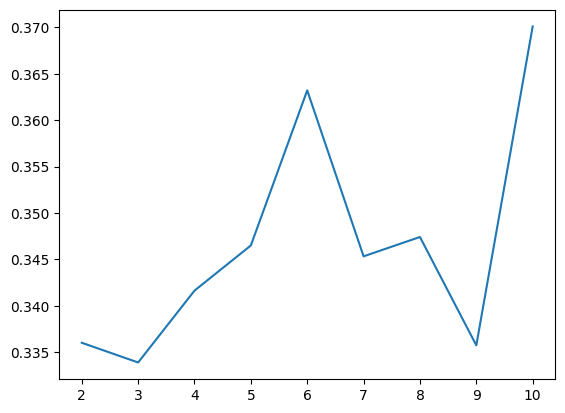

In [43]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

sil = []
kmax = 10

for k in range(2, kmax+1):
    kmeans = KMeans(n_clusters = k)
    labels = kmeans.fit_predict(df)
    sil.append(silhouette_score(df, labels))

plt.plot(range(2, kmax+1), sil)

Best = 10 clusters

### K-Means with 10 clusters

In [44]:
km_model = KMeans(n_clusters=10)
km_pred = km_model.fit_predict(df)

C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


## DBSCAN

In [45]:
from sklearn.cluster import DBSCAN

dbscan_model = DBSCAN(eps=0.5, min_samples=5)
dbscan_pred = dbscan_model.fit_predict(df)

## Agglomerative Clustering

In [46]:
from sklearn.cluster import AgglomerativeClustering

agg_model = AgglomerativeClustering(n_clusters=10)
agg_pred = agg_model.fit_predict(df)

# 1c. Visualizing clusters

## K-Means

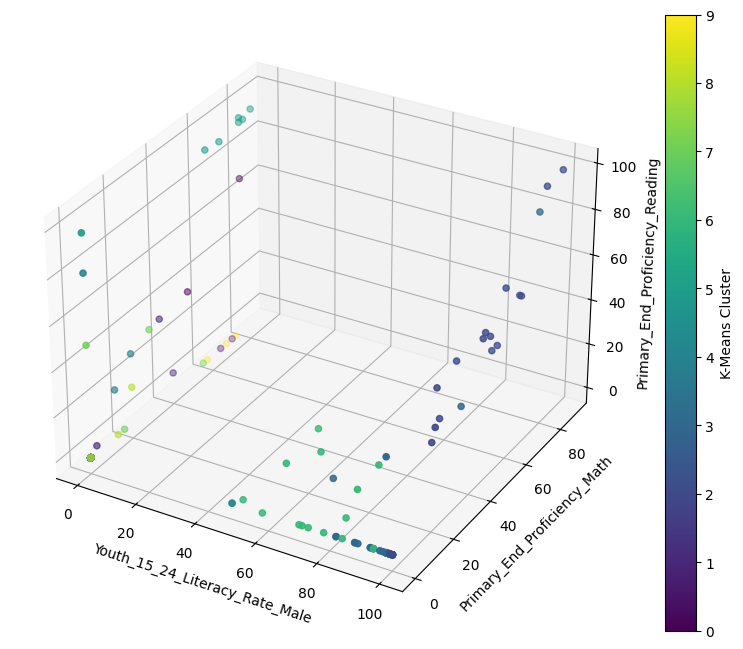

In [48]:
import matplotlib.pyplot as plt

# Create 3D Plot 
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter Plot with colors for based on cluster column
scatter = ax.scatter(df['Youth_15_24_Literacy_Rate_Male'], 
                     df['Primary_End_Proficiency_Math'], 
                     df['Primary_End_Proficiency_Reading'], 
                     c=km_pred, cmap='viridis')

# Add color bar
color_bar = fig.colorbar(scatter, ax=ax)
color_bar.set_label('K-Means Cluster')

# Set axis labels
ax.set_xlabel('Youth_15_24_Literacy_Rate_Male')
ax.set_ylabel('Primary_End_Proficiency_Math')
ax.set_zlabel('Primary_End_Proficiency_Reading')

# Show Plot
plt.show()

## DBSCAN

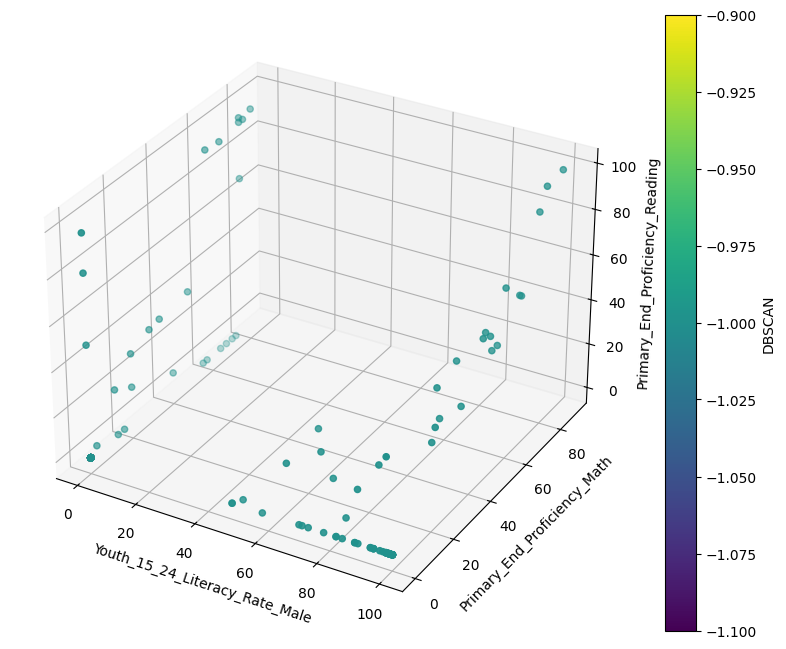

In [50]:
import matplotlib.pyplot as plt

# Create 3D Plot 
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter Plot with colors for based on cluster column
scatter = ax.scatter(df['Youth_15_24_Literacy_Rate_Male'], 
                     df['Primary_End_Proficiency_Math'], 
                     df['Primary_End_Proficiency_Reading'], 
                     c=dbscan_pred, cmap='viridis')

# Add color bar
color_bar = fig.colorbar(scatter, ax=ax)
color_bar.set_label('DBSCAN')

# Set axis labels
ax.set_xlabel('Youth_15_24_Literacy_Rate_Male')
ax.set_ylabel('Primary_End_Proficiency_Math')
ax.set_zlabel('Primary_End_Proficiency_Reading')

# Show Plot
plt.show()

## Agglomerative Clustering

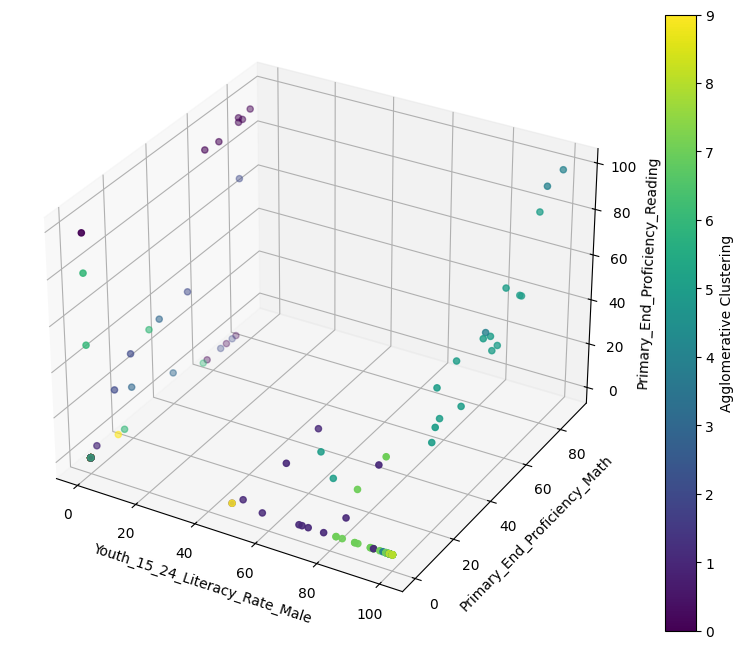

In [51]:
import matplotlib.pyplot as plt

# Create 3D Plot 
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter Plot with colors for based on cluster column
scatter = ax.scatter(df['Youth_15_24_Literacy_Rate_Male'], 
                     df['Primary_End_Proficiency_Math'], 
                     df['Primary_End_Proficiency_Reading'], 
                     c=agg_pred, cmap='viridis')

# Add color bar
color_bar = fig.colorbar(scatter, ax=ax)
color_bar.set_label('Agglomerative Clustering')

# Set axis labels
ax.set_xlabel('Youth_15_24_Literacy_Rate_Male')
ax.set_ylabel('Primary_End_Proficiency_Math')
ax.set_zlabel('Primary_End_Proficiency_Reading')

# Show Plot
plt.show()

# Penjeasannya Pribadi aja ya